In [1]:
%pip install nltk xgboost
import numpy as np 
import nltk
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split 
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier 
from sklearn.metrics import classification_report, f1_score
import warnings
warnings.filterwarnings("ignore")

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd


path = "../jigsaw-unintended-bias-in-toxicity-classification/"

dataset_files = [
   "all_data.csv",
    "test_private_expanded.csv",
    "test_public_expanded.csv",
    "train.csv",
    
]

combined_dfs = []

for file in dataset_files:
    
    df = pd.read_csv(path + file)
    if 'comment_text' in df.columns:
        label_col = 'target' if 'target' in df.columns else 'toxicity'
        sub_df = df[['comment_text', label_col]].rename(columns={'comment_text': 'Text', label_col: 'oh_label'})
        combined_dfs.append(sub_df.dropna())
    
    
    elif 'Text' in df.columns and 'oh_label' in df.columns:
        sub_df = df[['Text', 'oh_label']].dropna()
        combined_dfs.append(sub_df)


final_df = pd.concat(combined_dfs, ignore_index=True)
print("Data shape:", final_df.shape)


Data shape: (3999023, 2)


In [3]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vydhyamvishnusai/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
train_df = pd.read_csv(path + "train.csv")
train_df.columns

Index(['id', 'target', 'comment_text', 'severe_toxicity', 'obscene',
       'identity_attack', 'insult', 'threat', 'asian', 'atheist', 'bisexual',
       'black', 'buddhist', 'christian', 'female', 'heterosexual', 'hindu',
       'homosexual_gay_or_lesbian', 'intellectual_or_learning_disability',
       'jewish', 'latino', 'male', 'muslim', 'other_disability',
       'other_gender', 'other_race_or_ethnicity', 'other_religion',
       'other_sexual_orientation', 'physical_disability',
       'psychiatric_or_mental_illness', 'transgender', 'white', 'created_date',
       'publication_id', 'parent_id', 'article_id', 'rating', 'funny', 'wow',
       'sad', 'likes', 'disagree', 'sexual_explicit',
       'identity_annotator_count', 'toxicity_annotator_count'],
      dtype='str')

In [5]:
train_df['label'] = (train_df['target'] >= 0.5).astype(int)

In [6]:
features = ['comment_text']
target = 'label'

In [7]:
import pandas as pd
import re

train_df = pd.read_csv(path + "train.csv")
df = train_df[['comment_text', 'target']].copy()
df = df.dropna(subset=['comment_text', 'target'])
df['label'] = (df['target'] >= 0.5).astype(int)
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
df['clean_text'] = df['comment_text'].apply(preprocess_text)
df = df[df['clean_text'] != '']
df = df.drop_duplicates(subset=['clean_text'])
print(df.shape)
print(df[['clean_text', 'target', 'label']].head())

(1774308, 4)
                                          clean_text    target  label
0  this is so cool. it's like, 'would you want yo...  0.000000      0
1  thank you!! this would make my life a lot less...  0.000000      0
2  this is such an urgent design problem; kudos t...  0.000000      0
3  is this something i'll be able to install on m...  0.000000      0
4               haha you guys are a bunch of losers.  0.893617      1


In [ ]:
sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

ValueError: could not convert string to float: "This is so cool. It's like, 'would you want your mother to read this??' Really great idea, well done!"

In [8]:
X = df['clean_text']
y = df['label']

In [9]:
X

0          this is so cool. it's like, 'would you want yo...
1          thank you!! this would make my life a lot less...
2          this is such an urgent design problem; kudos t...
3          is this something i'll be able to install on m...
4                       haha you guys are a bunch of losers.
                                 ...                        
1804869    maybe the tax on "things" would be collected w...
1804870    what do you call people who still think the di...
1804871    thank you ,,,right or wrong,,, i am following ...
1804872    anyone who is quoted as having the following e...
1804873    students defined as ebd are legally just as di...
Name: clean_text, Length: 1774308, dtype: str

In [10]:
y

0          0
1          0
2          0
3          0
4          1
          ..
1804869    0
1804870    0
1804871    0
1804872    1
1804873    0
Name: label, Length: 1774308, dtype: int64

In [11]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,random_state=42,stratify=y
)


In [12]:
X_train

1699612    this marine died because of the gay pride para...
1741029    yes, we know. the constitution is your special...
1746191    some people can be pretty sensitive these days...
536863     “it’s absolutely devastating news for refugees...
1329380    not from the church anyway. but the priest who...
                                 ...                        
1190385    one party rule will corrupt and corrupt absolu...
1584634    secluded!!!!!! funny indeed when they have rig...
1225462    the editorial is right that "secrecy and doubl...
1288447                                     good stuff beer!
702976     your post is abusive and constitutes harassmen...
Name: clean_text, Length: 1419446, dtype: str

In [13]:
tfidf = TfidfVectorizer(max_features=10000,ngram_range=(1, 2),min_df=2,sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

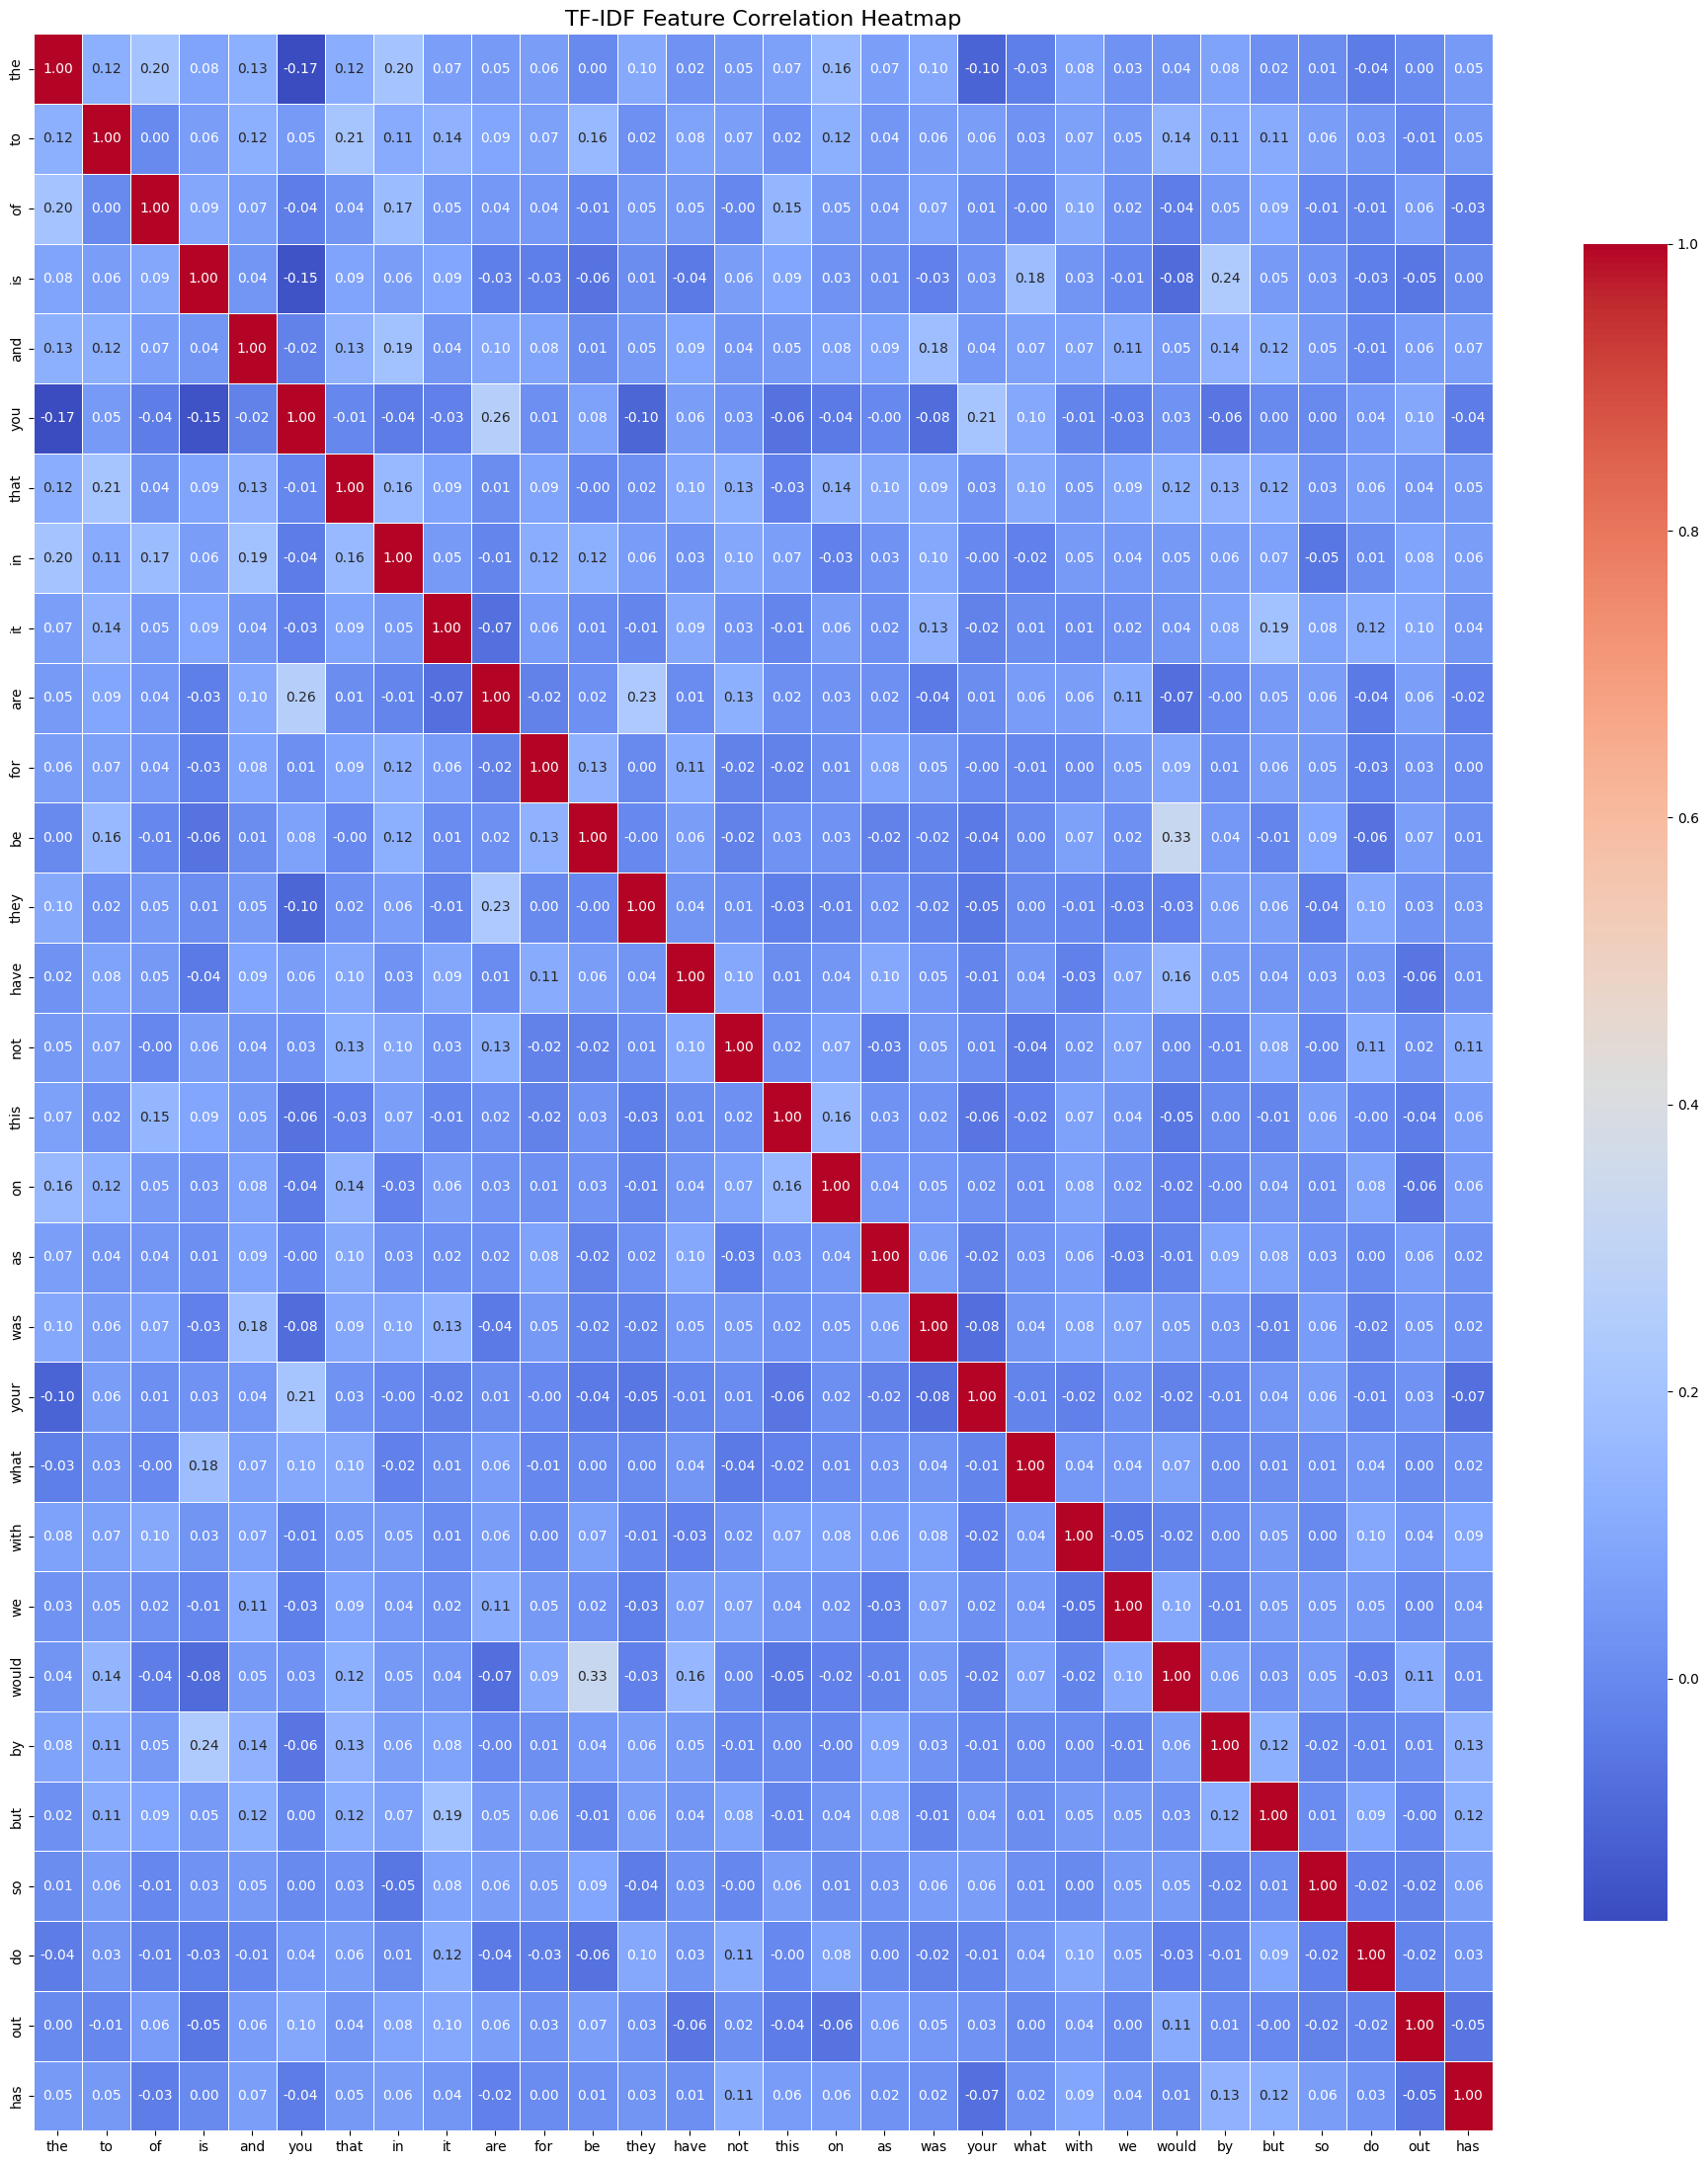

In [14]:
feature_df = pd.DataFrame(
    X_train_tfidf[:500].toarray(),
    columns=tfidf.get_feature_names_out()
)

# Use only the most informative features for a readable heatmap
selected_features = feature_df.abs().mean().sort_values(ascending=False).head(30).index

plt.figure(figsize=(19, 22))
sns.heatmap(
    feature_df[selected_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('TF-IDF Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

In [15]:
pd.DataFrame(
    X_train_tfidf[:5].toarray(),
    columns=tfidf.get_feature_names_out()
).columns

Index(['00', '000', '000 000', '10', '10 000', '10 million', '10 years', '100',
       '100 000', '100 of',
       ...
       'yours', 'yourself', 'yourselves', 'youth', 'youtube', 'yr', 'yup',
       'zero', 'zone', 'zuma'],
      dtype='str', length=10000)

In [18]:
scale = (y_train == 0).sum() / (y_train ==1).sum()


NameError: name 'model' is not defined

In [19]:
model = XGBClassifier(
    n_estimators=250,
    learning_rate=0.08,
    max_depth=7,
    scale_pos_weight=scale,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
    
)
model.fit(X_train_tfidf, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

In [20]:
y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.92      0.95    326466
           1       0.44      0.69      0.53     28396

    accuracy                           0.90    354862
   macro avg       0.70      0.81      0.74    354862
weighted avg       0.93      0.90      0.91    354862



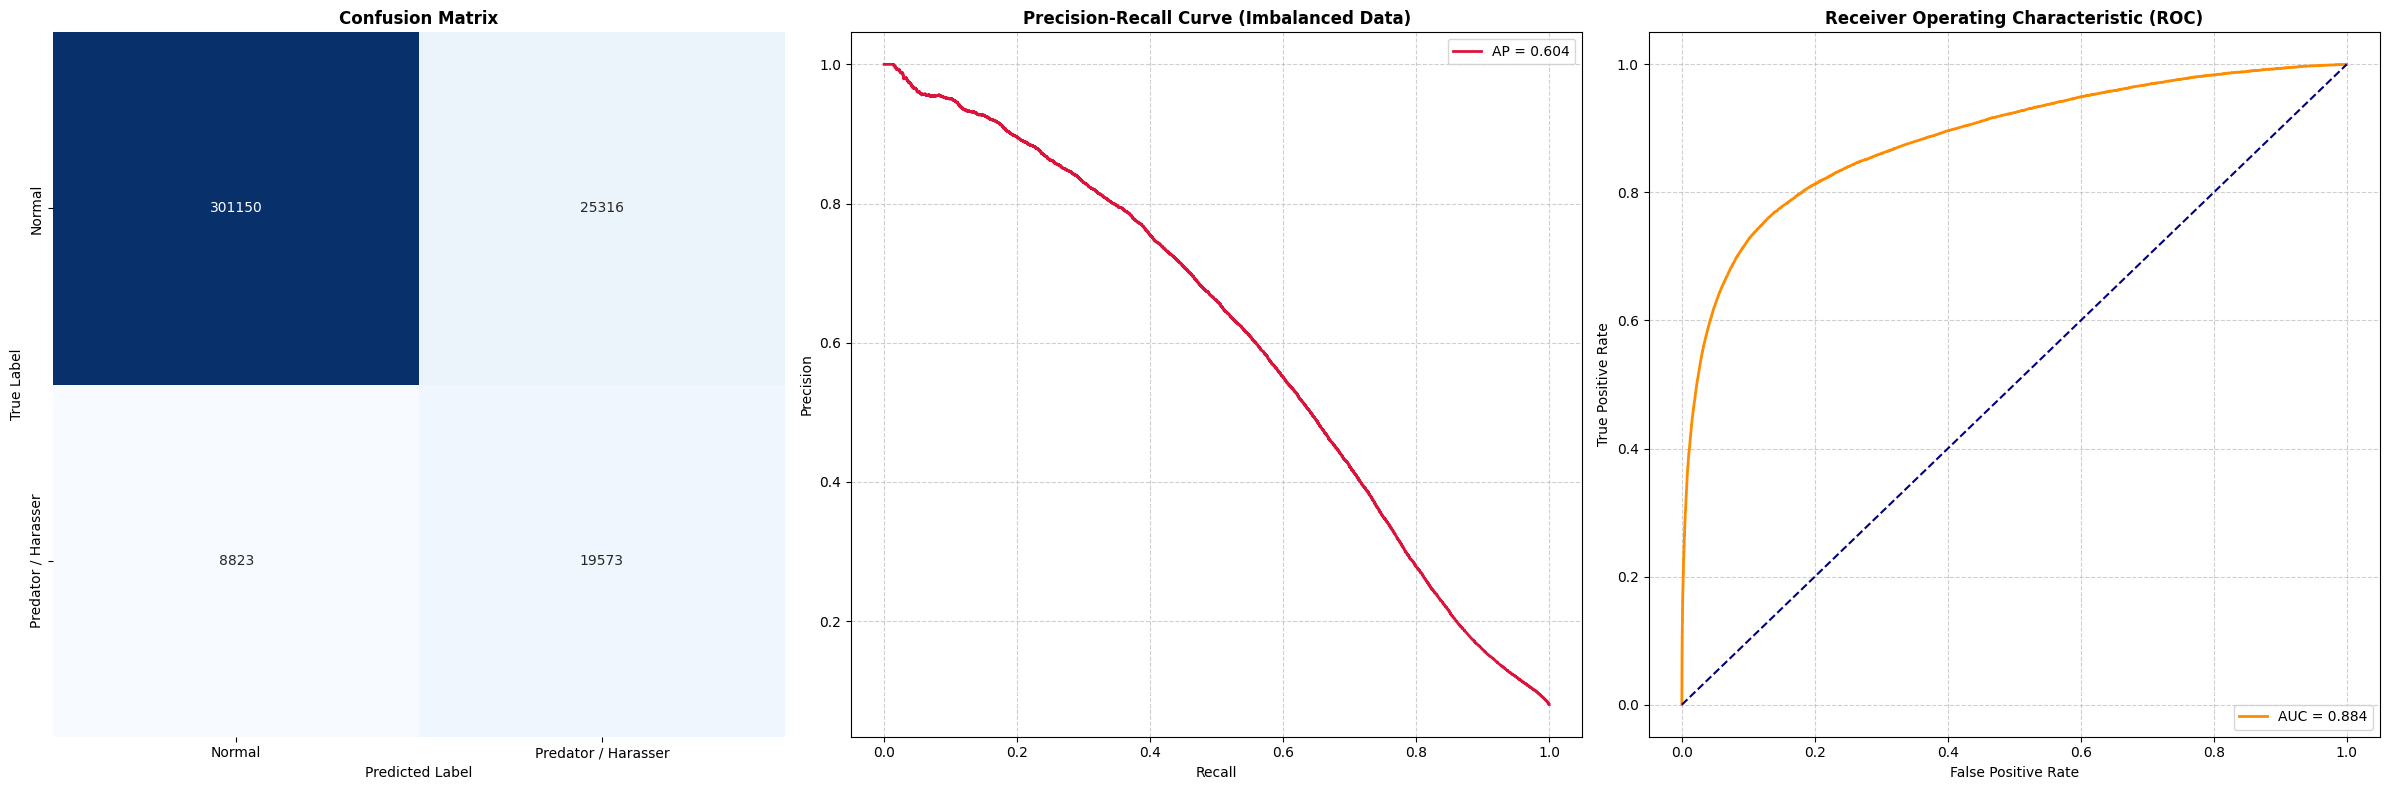

In [21]:
from sklearn.metrics import (
    confusion_matrix, 
    roc_curve, 
    auc, 
    precision_recall_curve, 
    average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns

y_probs = model.predict_proba(X_test_tfidf)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Normal', 'Predator / Harasser'],
    yticklabels=['Normal', 'Predator / Harasser'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_probs)
ap_score = average_precision_score(y_test, y_probs)
axes[1].plot(recall_vals, precision_vals, color='crimson', lw=2, label=f'AP = {ap_score:.3f}')
axes[1].set_title('Precision-Recall Curve (Imbalanced Data)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.6)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[2].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
axes[2].set_title('Receiver Operating Characteristic (ROC)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(loc='lower right')
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
feature_names = np.array(tfidf.get_feature_names_out())
feature_names

array(['00', '000', '000 000', ..., 'zero', 'zone', 'zuma'],
      shape=(10000,), dtype=object)